<a href="https://colab.research.google.com/github/norman-AI-2025/data-science-norman/blob/main/tuto11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup and Import Libraries

In [ ]:
# import libraries so your notebook can load data, plot graphs, run basic statistics, and display tables nicely
import numpy as np # NumPy (np): numerical operations (arrays, math, random sampling, etc.)
import pandas as pd # Pandas (pd): load and manipulate tabular data (CSV → DataFrame, filtering, groupby, merge)

import matplotlib.pyplot as plt # Matplotlib (plt): basic plotting (scatter, hist, line, etc.)
import seaborn as sns # Seaborn (sns): prettier statistical plots built on Matplotlib (boxplot, heatmap, regplot, etc.)

# train_test_split: splits data into train and test sets (e.g., 80/20) so we can evaluate on unseen data
# GridSearchCV: tries multiple hyperparameter combinations using cross-validation to find the best settings
from sklearn.model_selection import train_test_split, GridSearchCV

# ColumnTransformer: apply different preprocessing to different column types: numeric columns → impute missing values, categorical columns → impute + one-hot encode
# Pipeline: chain steps together (preprocess → model) so everything is consistent and leak-free
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Converts categorical columns (e.g., Gender, Education) into numeric binary columns (0/1) so the model can use them
from sklearn.preprocessing import OneHotEncoder

# Fills missing data: numeric → often median, categorical → most frequent
# Prevents the model from failing due to NaNs
from sklearn.impute import SimpleImputer

# These tell you how good your regression model is
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# DecisionTreeRegressor: the ML model you’ll train to predict a numeric target like Salary_USD
# plot_tree: draws the tree structure (splits/rules) for interpretation
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Pandas display formatting
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Fixes random operations (like train/test splitting randomness, sampling) so you will get consistent results each run
np.random.seed(42)

## 1) Load data (from Google Drive)

✅ Put both CSV files in the same folder on Google Drive

- `salary_cleaned.csv`
- `xtra_info.csv`

In [ ]:
# Mount Google Drive into Colab. Colab runs on a cloud VM. Your Drive is not available by default. When you run it, Colab will show an authentication link and ask you to authorize.
from google.colab import drive
drive.mount('/content/drive')

# Load CSV files into DataFrames (update the path if your folder name is different)
df_salary_cleaned = pd.read_csv('/content/drive/MyDrive/WIA1007/Dataset/salary_cleaned.csv') #load the csv dataset into a 'dataframe'
df_xtra_info = pd.read_csv('/content/drive/MyDrive/WIA1007/Dataset/xtra_info.csv') #load the csv dataset into a 'dataframe'

print("df_salary_cleaned:", df_salary_cleaned.shape)
print("df_xtra_info:  ", df_xtra_info.shape)

df_salary_cleaned.head()
df_xtra_info.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
df_salary_cleaned: (28012, 16)
df_xtra_info:   (13404, 4)


,USERID,CGPA,Salary_month_USD,Special Bonus_GBP
0,8683,2.990627,4583.333333,2437.0
1,3880,2.288131,5166.666667,740.0
2,8898,3.903324,5000.000000,3806.0
3,4441,2.470852,9333.333333,4691.0
4,7537,3.559457,3750.000000,4580.0


## 2) Merge correctly on `USERID` (important!)

**Why not `concat(axis=1)`?**  
Because the two files have **different row counts** and `xtra_info.csv` contains **duplicate USERIDs**.  
So we must:
1. Aggregate `xtra_info.csv` to one row per `USERID`
2. `merge` on `USERID` (left join)

We’re checking for duplicate IDs, compressing xtra_info into one row per user, then left-merging it into the salary dataset to build a clean master table for decision tree training.

In [ ]:
# Check duplicates in USERID: duplicated() marks rows where USERID has appeared before and .sum() counts how many duplicates exist.
print("Duplicate USERIDs in salary:", df_salary_cleaned["USERID"].duplicated().sum())
print("Duplicate USERIDs in xtra:  ", df_xtra_info["USERID"].duplicated().sum())

# Aggregate xtra_info to one row per USERID (mean of numeric values)
df_xtra_agg = df_xtra_info.groupby("USERID", as_index=False).agg({
    "CGPA": "mean",
    "Salary_month_USD": "mean",
    "Special Bonus_GBP": "mean"
})

print("df_xtra_agg:", df_xtra_agg.shape)
df_xtra_agg.head()

# Left join: keep all salary rows, attach extra info where possible
df = df_salary_cleaned.merge(df_xtra_agg, on="USERID", how="left")
print("MASTER df:", df.shape)
df.head()

Duplicate USERIDs in salary: 0
Duplicate USERIDs in xtra:   4962
df_xtra_agg: (8442, 4)
MASTER df: (28012, 19)


,USERID,Age,Industry,Job title,Salary,Compensation,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race,Salary_USD,Compensation_USD,CGPA,Salary_month_USD,Special Bonus_GBP
0,0,25-34,Education (Higher Education),Research and Instruction Librarian,55000.0,0.0,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White,55000.0,0.0,NaN,NaN,NaN
1,1,25-34,Computing or Tech,Change & Internal Communications Manager,54600.0,4000.0,United Kingdom,Unknown,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White,68250.0,5000.0,2.695615,4250.0,125.0
2,2,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000.0,2000.0,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White,34000.0,2000.0,NaN,NaN,NaN
3,3,25-34,Nonprofits,Program Manager,62000.0,3000.0,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White,62000.0,3000.0,NaN,NaN,NaN
4,4,25-34,"Accounting, Banking & Finance",Accounting Manager,60000.0,7000.0,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White,60000.0,7000.0,2.689383,12500.0,1133.0


## 3) Quick audit (missing values + target column)

Our goal: **Salary_USD** (numeric regression target)

Quickly identify columns that are mostly empty (might need to drop or impute) and confirm the prediction target exists, has enough data, and inspect its scale/outliers.

In [ ]:
df.isna().mean().sort_values(ascending=False).head(10)

# Check feature availability. If a feature has > 50–70% missing, it’s often better to drop it (unless it’s critical and you have a good imputation plan)
df["Salary_USD"].isna().mean(), df["Salary_USD"].describe()

(np.float64(0.0010352705983150078),
 count     27983.000000
 mean      83824.093875
 std       42513.504410
 min           0.265000
 25%       52545.000000
 50%       74000.000000
 75%      105000.000000
 max      241562.500000
 Name: Salary_USD, dtype: float64)

## 4) Feature engineering: convert bins to numeric midpoints

Some columns are stored as *bins* (text), e.g.:
- `Age`: "25-34"
- `Overall years of experience`: "11 - 20 years"

Decision trees can use numeric values better for regression, so we create:
- `Age_mid`
- `Exp_mid`
- `Exp_current_mid`

This function converts text “range/bin” values like "25-34" or "11 - 20 years" into an approximate numeric midpoint (e.g., 29.5 or 15.5) so the model can use them as numbers and if it can’t interpret the text, it returns NaN.

Then it applies the function to the Age and experience columns to create new numeric features (Age_mid, Exp_mid, Exp_current_mid) and previews the original vs converted values.

In [ ]:
def midpoint_from_bin(text):
    """Convert a bin string into an approximate numeric midpoint.
    Handles examples like:
      '25-34', '11 - 20 years', '1 year or less', '41 years or more', '65 or over'
    Returns np.nan if it cannot parse.
    """
    if pd.isna(text):
        return np.nan
    s = str(text).strip().lower()

    # special cases
    if "under 18" in s:
        return 16.0
    if "65" in s and ("over" in s or "or over" in s):
        return 67.5
    if "41" in s and ("more" in s or "or more" in s):
        return 45.0
    if "1 year or less" in s:
        return 0.5

    # remove words
    s = s.replace("years", "").replace("year", "").replace(" ", "")

    # patterns like 25-34 or 11-20
    if "-" in s:
        parts = s.split("-")
        try:
            a = float(parts[0])
            b = float(parts[1])
            return (a + b) / 2.0
        except:
            return np.nan

    return np.nan

df["Age_mid"] = df["Age"].apply(midpoint_from_bin)
df["Exp_mid"] = df["Overall years of experience"].apply(midpoint_from_bin)
df["Exp_current_mid"] = df["Years of experience in current job"].apply(midpoint_from_bin)

df[["Age", "Age_mid", "Overall years of experience", "Exp_mid", "Years of experience in current job", "Exp_current_mid"]].head(12)

,Age,Age_mid,Overall years of experience,Exp_mid,Years of experience in current job,Exp_current_mid
0,25-34,29.5,5-7 years,6.0,5-7 years,6.0
1,25-34,29.5,8 - 10 years,9.0,5-7 years,6.0
2,25-34,29.5,2 - 4 years,3.0,2 - 4 years,3.0
3,25-34,29.5,8 - 10 years,9.0,5-7 years,6.0
4,25-34,29.5,8 - 10 years,9.0,5-7 years,6.0
5,25-34,29.5,8 - 10 years,9.0,2 - 4 years,3.0
6,25-34,29.5,2 - 4 years,3.0,2 - 4 years,3.0
7,25-34,29.5,5-7 years,6.0,5-7 years,6.0
8,45-54,49.5,21 - 30 years,25.5,21 - 30 years,25.5
9,35-44,39.5,21 - 30 years,25.5,21 - 30 years,25.5


## 5) Choose features (avoid leakage)

**Leakage** = using information that is basically the answer.

For example, `Salary_month_USD` is strongly related to annual salary.  
To keep learning meaningful, we will **exclude** it from features by default.

We will use:
- Numeric features: `Age_mid`, `Exp_mid`, `Exp_current_mid`, `CGPA`, `Special Bonus_GBP`
- Categorical features: `Industry`, `Country`, `State`, `Education level`, `Gender`, `Race`
- Optional (high-cardinality): `Job title`, `City`

This code reduces “high-cardinality” categorical columns (like Job title and City) by keeping only the top K most frequent values and replacing all other categories with "Other", which prevents exploding one-hot encoded features.

Then it defines the target (Salary_USD) and the selected numeric/categorical feature lists, filters out any missing columns for safety, and prints the final feature sets.

In [ ]:
# OPTIONAL: reduce high-cardinality columns by keeping top-K and mapping others to 'Other'
def keep_top_k(df, col, k=20):
    top = df[col].value_counts().head(k).index
    df[col] = df[col].where(df[col].isin(top), other="Other")
    return df

# Apply to Job title and City (helps avoid too many one-hot columns)
df = keep_top_k(df, "Job title", k=25)
df = keep_top_k(df, "City", k=25)

# Define target and feature columns
target = "Salary_USD"

numeric_features = ["Age_mid", "Exp_mid", "Exp_current_mid", "CGPA", "Special Bonus_GBP"]
categorical_features = ["Industry", "Country", "State", "Education level", "Gender", "Race", "Job title", "City"]

# Remove any features not present (safety)
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age_mid', 'Exp_mid', 'Exp_current_mid', 'CGPA', 'Special Bonus_GBP']
Categorical features: ['Industry', 'Country', 'State', 'Education level', 'Gender', 'Race', 'Job title', 'City']


## 6) Train/test split

We split the data:
- **Train (80%)**: used to learn the model
- **Test (20%)**: held out for final evaluation

This code removes rows where the target (Salary_USD) is missing, then splits the remaining data into features X and target y.

Finally, it performs an 80/20 train–test split (with a fixed random seed for reproducibility) and prints the training and test set sizes.

In [ ]:
# Drop rows where target is missing
df_model = df.dropna(subset=[target]).copy()

X = df_model[numeric_features + categorical_features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((22386, 13), (5597, 13))

## 7) Build a preprocessing + Decision Tree pipeline

### Why a pipeline?
- **Imputation**: fill missing numeric values (median) and missing categorical values (most frequent)
- **One-hot encoding**: convert categories to numbers for the model
- **Decision Tree Regressor**: fits non-linear decision rules

This code builds a preprocessing pipeline that imputes missing numeric values with the median and imputes + one-hot encodes categorical values, then combines these transformations using a ColumnTransformer.

It wraps the preprocessing together with a DecisionTreeRegressor into one end-to-end Pipeline so training and prediction always apply the same data preparation steps.

In [ ]:
# Preprocessing for numeric: fill missing values with median
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Preprocessing for categorical: fill missing + one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

tree = DecisionTreeRegressor(
    random_state=42
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("tree", tree)
])

model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age_mid', 'Exp_mid',
                                                   'Exp_current_mid', 'CGPA',
                                                   'Special Bonus_GBP']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Industry', 'Country',
                                                   'State', 'Education level',
                                                   'Gender', 'Race',
                                                   'Job title', 'City'])])),
                ('tree', DecisionTreeRegressor(random_state=42))])

## 8) Baseline vs Decision Tree

Before a “smart” model, always compare to a baseline.

Baseline: predict **mean salary of training set** for everyone.

This code creates a simple baseline model that predicts the same value for every test sample—the mean salary from the training set—and then evaluates it using MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R² (Coefficient of Determination).

The printed metrics provide a minimum reference point to compare against the decision tree’s performance.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Baseline predictor
y_pred_baseline = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

mae_base = mean_absolute_error(y_test, y_pred_baseline)
rmse_base = mean_squared_error(y_test, y_pred_baseline) #, squared=False)
r2_base = r2_score(y_test, y_pred_baseline)

print("Baseline (mean prediction)")
print("MAE :", round(mae_base, 2))
print("RMSE:", round(rmse_base, 2))
print("R^2 :", round(r2_base, 4))

Baseline (mean prediction)
MAE : 33356.26
RMSE: 1765652980.85
R^2 : -0.0001


**MAE (Mean Absolute Error):**

Definition: average of the absolute prediction errors.

Interpretation: “On average, my predictions are off by MAE dollars.”

Pros: easy to understand, less sensitive to extreme outliers than RMSE.

**RMSE (Root Mean Squared Error)**:

Definition: square root of the average squared errors.

Interpretation: also in dollars, but it penalizes large mistakes more than MAE.

When useful: when big errors are especially bad (e.g., predicting salary very wrong).

**R² (Coefficient of Determination)**:

Definition: how much of the variance in y the model explains compared to predicting the mean.

Interpretation:

1.0 = perfect predictions

0.0 = no better than predicting the mean every time (baseline)

negative = worse than the mean baseline

Example: R² = 0.35 means the model explains ~35% of the variability in salary.

This code trains the end-to-end pipeline (preprocessing + decision tree regressor) on the training data, then uses it to predict salaries on the test set.

It evaluates the predictions using MAE, RMSE, and R² and prints the decision tree’s performance metrics.

In [ ]:
# Fit decision tree
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) #, squared=False)
r2 = r2_score(y_test, y_pred)

print("Decision Tree Regressor")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R^2 :", round(r2, 4))

Decision Tree Regressor
MAE : 30586.12
RMSE: 1776063830.22
R^2 : -0.006


### ✅ TODO 1 (Students)
Compare baseline vs decision tree:
1. Which model has lower MAE / RMSE?
2. Is R² improved?

Write 2–3 sentences.

## 9) Visualize a shallow tree (readable)

A full tree can be huge. We fit a **small depth tree** and plot it so you can see the decision rules.

This code trains a shallow decision tree (limited to max_depth=3) using the same preprocessing steps so the model stays small enough to interpret. It then extracts the fitted tree and visualizes its split rules and predicted values using plot_tree

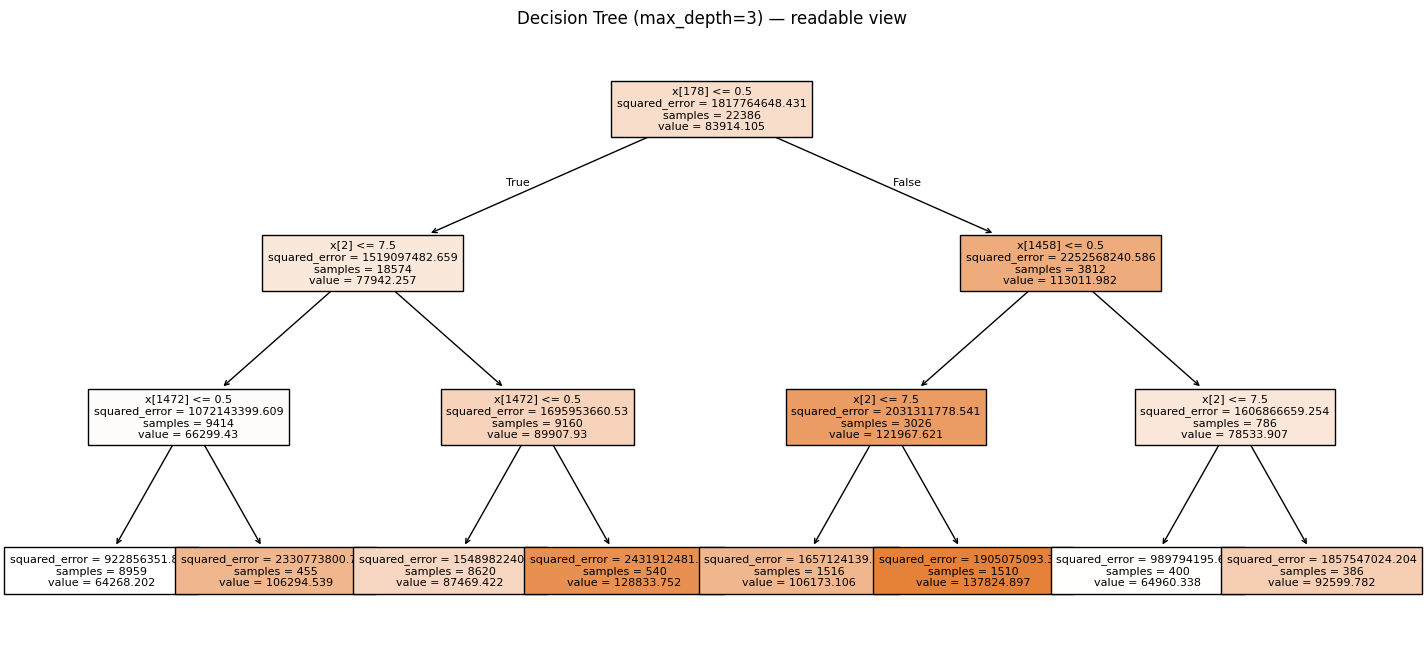

In [ ]:
# Train a shallow tree just for visualization
viz_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("tree", DecisionTreeRegressor(max_depth=3, random_state=42))
])

viz_model.fit(X_train, y_train)

# Extract the fitted tree from the pipeline
fitted_tree = viz_model.named_steps["tree"]

plt.figure(figsize=(18, 8))
plot_tree(fitted_tree, filled=True, max_depth=3, fontsize=8)
plt.title("Decision Tree (max_depth=3) — readable view")
plt.show()

## 10) Feature importance (what matters most?)

Decision trees can report which features were most useful to reduce error.

⚠️ With one-hot encoding, each category becomes a separate feature.
We will display the **top 20** most important features.

This code extracts the final feature names after preprocessing (original numeric features plus one-hot encoded categorical feature names), then pairs them with the decision tree’s feature_importances_ scores. It creates a sorted table showing the top 20 most influential features used by the tree to make salary predictions.

In [ ]:
# Get feature names after preprocessing (works in recent scikit-learn)
pre = model.named_steps["preprocess"]
tree_fitted = model.named_steps["tree"]

# Numeric names
num_names = numeric_features

# Categorical one-hot names
cat_ohe = pre.named_transformers_["cat"].named_steps["onehot"]
cat_names = cat_ohe.get_feature_names_out(categorical_features)

feature_names = np.concatenate([num_names, cat_names])

importances = tree_fitted.feature_importances_
imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

imp.head(20)

,0
Exp_current_mid,0.122811
Industry_Computing or Tech,0.096520
State_Unknown,0.061051
"Education level_Professional degree (MD, JD, etc.)",0.041336
CGPA,0.035736
Special Bonus_GBP,0.032878
Exp_mid,0.031852
Age_mid,0.027008
City_Other,0.024420
State_California,0.017218


This code visualizes the top 20 most important features from the decision tree by plotting them as a horizontal bar chart. The iloc[::-1] reverses the order so the most important feature appears at the top (making the chart easier to read).

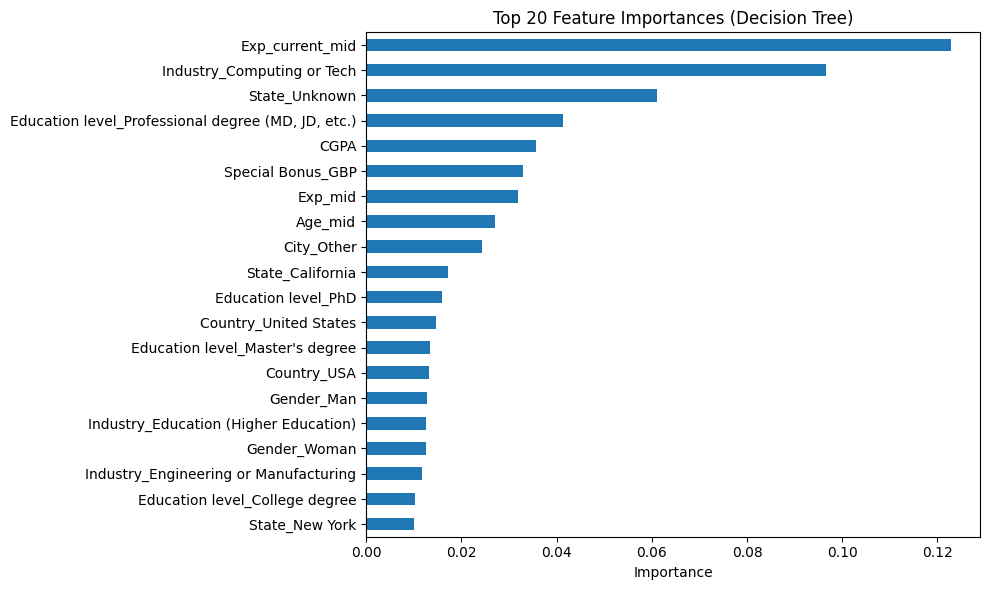

In [ ]:
# Plot top 20 importances
topk = 20
plt.figure(figsize=(10, 6))
imp.head(topk).iloc[::-1].plot(kind="barh")
plt.title("Top 20 Feature Importances (Decision Tree)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### ✅ TODO 2 (Students)
Look at the top 5 features:
- Are they reasonable?  
- Which feature surprises you most?

## 11) Overfitting demo: depth vs train/test performance

Deeper trees fit training data better, but can overfit.

We will train trees with different `max_depth` values and compare:
- Train R²
- Test R²

This code trains decision trees with depths 1–20, plots train vs test R² to show how depth affects overfitting, and prints the depth that achieves the best test R².

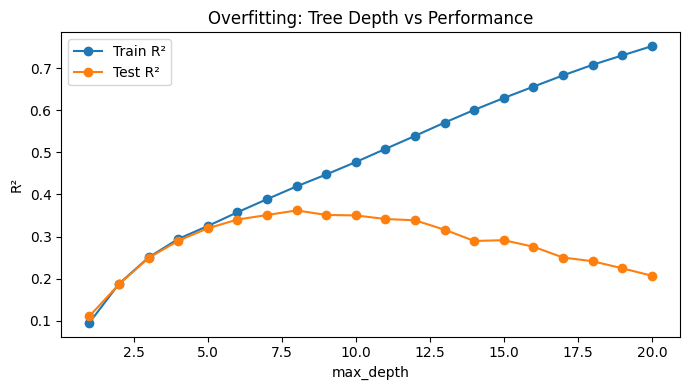

Best test R² depth (approx): 8  with test R² = 0.3620607479058774


In [ ]:
depths = list(range(1, 21))
train_r2 = []
test_r2 = []

for d in depths:
    m = Pipeline(steps=[
        ("preprocess", preprocess),
        ("tree", DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    m.fit(X_train, y_train)
    train_r2.append(m.score(X_train, y_train))
    test_r2.append(m.score(X_test, y_test))

plt.figure(figsize=(7, 4))
plt.plot(depths, train_r2, marker="o", label="Train R²")
plt.plot(depths, test_r2, marker="o", label="Test R²")
plt.xlabel("max_depth")
plt.ylabel("R²")
plt.title("Overfitting: Tree Depth vs Performance")
plt.legend()
plt.tight_layout()
plt.show()

best_depth = depths[int(np.argmax(test_r2))]
print("Best test R² depth (approx):", best_depth, " with test R² =", max(test_r2))

### ✅ TODO 3 (Students)
From the plot:
1. At what depth does test R² peak?
2. Explain “overfitting” in 1–2 sentences.

## 12) Hyperparameter tuning (GridSearchCV)

Now we tune key parameters using cross-validation:
- `max_depth`
- `min_samples_leaf`
- `min_samples_split`

We use **neg_root_mean_squared_error** as the scoring metric.

This code uses GridSearchCV with 3-fold cross-validation to try different decision-tree hyperparameter combinations (max_depth, min_samples_leaf, min_samples_split), selecting the best settings that minimize RMSE and printing the best parameters and cross-validated RMSE.

In [ ]:
param_grid = {
    "tree__max_depth": [3, 5, 8, 12, None],
    "tree__min_samples_leaf": [1, 5, 20, 50],
    "tree__min_samples_split": [2, 10, 50, 100],
}

grid = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

Best params: {'tree__max_depth': None, 'tree__min_samples_leaf': 20, 'tree__min_samples_split': 100}
Best CV RMSE: 33171.03816428099


This code takes the best tuned model from GridSearch, predicts salaries on the test set, computes MAE/RMSE/R², and prints the tuned decision tree’s test performance.

In [ ]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

mae_b = mean_absolute_error(y_test, y_pred_best)
rmse_b = mean_squared_error(y_test, y_pred_best) #, squared=False)
r2_b = r2_score(y_test, y_pred_best)

print("Tuned Decision Tree (Test)")
print("MAE :", round(mae_b, 2))
print("RMSE:", round(rmse_b, 2))
print("R^2 :", round(r2_b, 4))

Tuned Decision Tree (Test)
MAE : 24016.13
RMSE: 1037882975.76
R^2 : 0.4121


### ✅ TODO 4 (Students)
Did tuning improve test RMSE or R² compared to the untuned tree?
Write 2 sentences.

### Key takeaways
- **Decision Trees** split the data using rules like `Exp_mid <= 12.5`
- Trees are easy to interpret, but can **overfit** if too deep
- Use **train/test** + metrics (MAE/RMSE/R²) to evaluate
- Tune `max_depth`, `min_samples_leaf`, `min_samples_split` for better generalization
- One-hot encoding is needed for categorical features

### Common mistakes
- Using `concat(axis=1)` instead of `merge` when row counts differ
- Forgetting to handle missing values
- Interpreting training score only (overfitting!)